In [1]:
import cv2 

img = cv2.imread('/Users/dev/Desktop/IA/CNN/animal_images/ballena/aug_ballena_0_6.jpg')

print(img.shape[0], img.shape[1], img.shape[2], len(img.shape))

64 64 3 3


In [3]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.11/bin/python3.11


# Convolutional Neural Networks

# Importar Librerías

In [27]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical

In [28]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [29]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

dirname = "/Users/dev/Desktop/IA/CNN/animal_images" 
imgpath = dirname + os.sep 

# --- CONFIGURACIÓN DE SEGURIDAD ---
ALTO, ANCHO = 64, 64  # El tamaño exacto que espera tu red
CANALES = 3           # RGB (color)

images = []
labels = [] 
directories = []
dircount = []
prevRoot=''
cant = 0
errores = 0

print("🚀 Iniciando lectura blindada en:", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        
        # ARREGLO 1: Quitamos el 're.search' y usamos 'endswith'. 
        # Esto elimina el error rojo de '\.' y además usa .lower() para que lea mayúsculas y minúsculas sin fallar.
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp', '.jfif')):
            filepath = os.path.join(root, filename)
            
            # 🛠️ ARREGLO 2: Arreglamos la "Impresión Desfasada".
            # Antes, tu código imprimía tarde. Ahora, en el instante en que detecta que entró a una carpeta nueva,
            # imprime el conteo de la carpeta ANTERIOR, y luego resetea todo a cero.
            if prevRoot != root:
                if prevRoot != '': # Para que no imprima vacío la primera vez
                    print(f"\n📂 Carpeta TERMINADA: {prevRoot} | Imágenes válidas: {cant}")
                    directories.append(prevRoot)
                    dircount.append(cant)
                prevRoot = root
                cant = 0 # Empezamos a contar desde cero para la nueva carpeta

            try:
                # 1. Leemos la imagen
                image = plt.imread(filepath)
                if image is None:
                    errores += 1
                    continue
                
                # 2. Forzamos el redimensionamiento
                image_res = cv2.resize(image, (ANCHO, ALTO))
                
                # 3. Verificamos que tenga 3 canales (RGB)
                if len(image_res.shape) == 3 and image_res.shape[2] == CANALES:
                    images.append(image_res)
                    labels.append(os.path.basename(root))
                    
                    cant += 1
                else:
                    errores += 1
                    continue 

            except Exception as e:
                errores += 1
                continue

            b = f"Leyendo... {cant} (Errores saltados: {errores})"
            print(b, end="\r")

# ARREGLO 4: Como el bucle termina, la ÚLTIMA carpeta se quedaba sin imprimir.
# Con esto forzamos a que imprima e incluya la última carpeta que leyó (ej. 'ranas').
if prevRoot != '':
    print(f"\n📂 Carpeta TERMINADA: {prevRoot} | Imágenes válidas: {cant}")
    directories.append(prevRoot)
    dircount.append(cant)

print('\n' + "="*40)
print(f'✅ Proceso terminado con éxito')
print(f'📊 Imágenes totales cargadas: {len(images)}')
print(f'⚠️ Imágenes ignoradas por error: {errores}')
print("="*40)

# AHORA SÍ, esto ya no te dará errores en el futuro
y = np.array(labels) 
X = np.array(images, dtype=np.uint8) 
print("💎 Array de NumPy creado correctamente con forma:", X.shape)
print("💎 Etiquetas generadas:", y.shape)

🚀 Iniciando lectura blindada en: /Users/dev/Desktop/IA/CNN/animal_images/
Leyendo... 6330 (Errores saltados: 0)
📂 Carpeta TERMINADA: /Users/dev/Desktop/IA/CNN/animal_images/mono | Imágenes válidas: 6330
Leyendo... 6397 (Errores saltados: 0)
📂 Carpeta TERMINADA: /Users/dev/Desktop/IA/CNN/animal_images/ranas | Imágenes válidas: 6397
Leyendo... 6357 (Errores saltados: 0)
📂 Carpeta TERMINADA: /Users/dev/Desktop/IA/CNN/animal_images/arana | Imágenes válidas: 6357
Leyendo... 7390 (Errores saltados: 0)
📂 Carpeta TERMINADA: /Users/dev/Desktop/IA/CNN/animal_images/pajaro | Imágenes válidas: 7390
Leyendo... 6398 (Errores saltados: 0)
📂 Carpeta TERMINADA: /Users/dev/Desktop/IA/CNN/animal_images/ballena | Imágenes válidas: 6398

✅ Proceso terminado con éxito
📊 Imágenes totales cargadas: 32872
⚠️ Imágenes ignoradas por error: 0
💎 Array de NumPy creado correctamente con forma: (32872, 64, 64, 3)
💎 Etiquetas generadas: (32872,)


# Creamos las etiquetas

In [30]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  32872


In [31]:
deportes=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    deportes.append(name[len(name)-1])
    indice=indice+1

0 mono
1 ranas
2 arana
3 pajaro
4 ballena


In [32]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [33]:
# 1. Verificamos cuánto tiene cada uno
print(f"Imágenes (X): {len(images)}")
print(f"Etiquetas (y): {len(labels)}")

# 2. El truco de seguridad: Forzamos a que tengan el mismo tamaño
# Si una lista es más larga, cortamos el sobrante para que coincidan perfectamente
min_samples = min(len(images), len(labels))
images = images[:min_samples]
labels = labels[:min_samples]

# 3. Ahora sí, convertimos a NumPy con total seguridad
import numpy as np
X = np.array(images, dtype=np.uint8)
y = np.array(labels)

print(f"✅ Sincronización completa. Nuevo total: {len(X)}")

Imágenes (X): 32872
Etiquetas (y): 32872
✅ Sincronización completa. Nuevo total: 32872


In [34]:
from sklearn.model_selection import train_test_split

train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (26297, 64, 64, 3) (26297,)
Testing data shape :  (6575, 64, 64, 3) (6575,)


Text(0.5, 1.0, 'Ground Truth : 3')

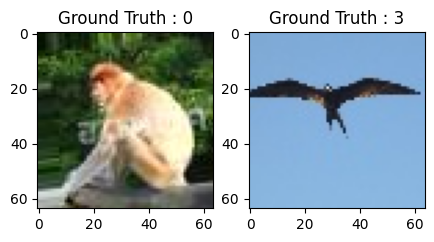

In [35]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

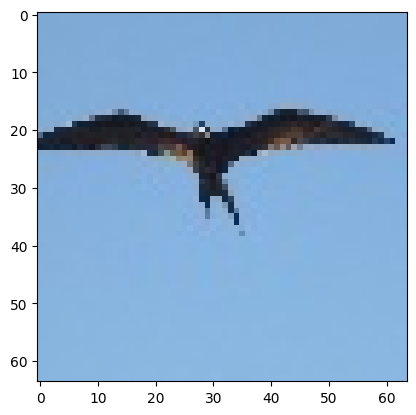

In [36]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [37]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 0
After conversion to one-hot: [1. 0. 0. 0. 0.]


# Creamos el Set de Entrenamiento y Validación

In [38]:
# creamos set de entrenamiento y validacion
from sklearn.model_selection import train_test_split

train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, 
    test_size=0.2, 
    random_state=13
)

In [39]:
print(train_X.shape, valid_X.shape, train_label.shape, valid_label.shape)

(21037, 64, 64, 3) (5260, 64, 64, 3) (21037, 5) (5260, 5)


# Creamos el modelo de CNN

In [49]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 30 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 32 # cantidad de imágenes que se toman a la vez en memoria

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Importamos las herramientas de mutación
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation

sport_model = Sequential()



sport_model.add(RandomFlip("horizontal", input_shape=(64, 64, 3))) 

sport_model.add(RandomRotation(0.10)) 

sport_model.add(RandomZoom(0.05)) 

sport_model.add(RandomTranslation(height_factor=0.05, width_factor=0.05)) 
# ======================================================================


# --- Detectar bordes y colores básicos ---
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
sport_model.add(MaxPooling2D(pool_size=(2, 2))) 

# ---  Detectar texturas (plumas, pelo, hojas) ---
sport_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
sport_model.add(MaxPooling2D(pool_size=(2, 2)))

# --- Detectar partes del cuerpo (ojos, alas, patas) ---
sport_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
sport_model.add(MaxPooling2D(pool_size=(2, 2)))

# --- BLOQUE DE TOMA DE DECISIONES ---
sport_model.add(Flatten()) 
sport_model.add(Dense(128, activation='relu'))
sport_model.add(Dropout(0.5)) 

# --- SALIDA FINAL ---
sport_model.add(Dense(5, activation='softmax'))

In [51]:
sport_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,597 (4.36 MB)

 Trainable params: 1,142,597 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
sport_model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

# Entrenamos el modelo: Aprende a clasificar imágenes

In [53]:
print("🚀 Iniciando tu entrenamiento manual con set de validación...")
sport_train = sport_model.fit(
    train_X, train_label,  # <-- Usamos la variable de la celda recuperada
    epochs=30,                 
    batch_size=32, 
    validation_data=(valid_X, valid_label), # <-- Usamos los de validación, no los de test
    callbacks=[early_stop, reduce_lr]
)
print("✅ Entrenamiento finalizado.")

🚀 Iniciando tu entrenamiento manual con set de validación...
Epoch 1/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.5413 - loss: 1.0909 - val_accuracy: 0.6800 - val_loss: 0.8214 - learning_rate: 0.0010
Epoch 2/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.6695 - loss: 0.8462 - val_accuracy: 0.7158 - val_loss: 0.7300 - learning_rate: 0.0010
Epoch 3/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.7209 - loss: 0.7370 - val_accuracy: 0.7065 - val_loss: 0.7929 - learning_rate: 0.0010
Epoch 4/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.7520 - loss: 0.6599 - val_accuracy: 0.7247 - val_loss: 0.7461 - learning_rate: 0.0010
Epoch 5/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.7732 - loss: 0.6066 - val_accuracy: 0.7719 - val_loss: 0.6002 - learning_rate: 0.0010
Epoch 6/30
658/658 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.7895 - loss: 0.5666 - val_accuracy: 0.7994 - val_loss: 0.5922 - learning_rate: 0.0010
Epoch 7/30
658/

In [54]:
# Obligamos a Python a guardarlo en tu directorio raíz
sport_model.save("/Users/dev/Desktop/IA/CNN/riesgo1.keras")
print("¡Archivo riesgo.keras guardado exitosamente")

¡Archivo riesgo.keras guardado exitosamente


# Evaluamos la red

In [56]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8689 - loss: 0.3589


In [57]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.35890865325927734
Test accuracy: 0.8688973188400269


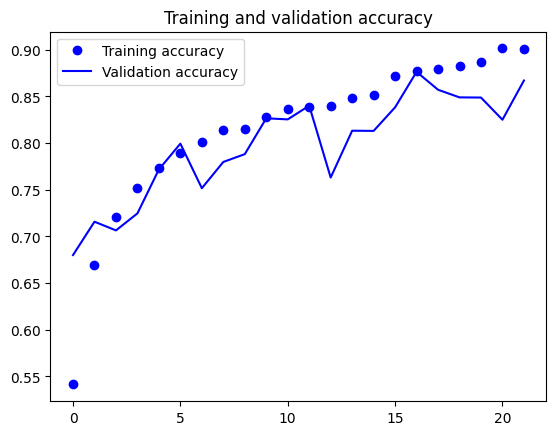

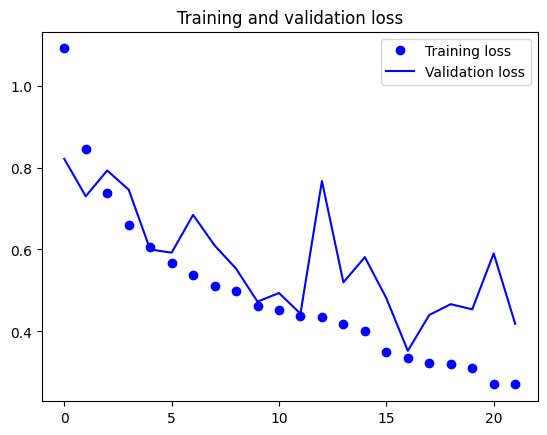

In [58]:

accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs = range(len(accuracy))

plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [60]:
predicted_classes2 = sport_model.predict(test_X)

206/206 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [61]:
predicted_classes=[]
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes=np.array(predicted_classes)

In [62]:
predicted_classes.shape, test_Y.shape

((6575,), (6575,))

# Aprendamos de los errores: Qué mejorar

Found 5713 correct labels


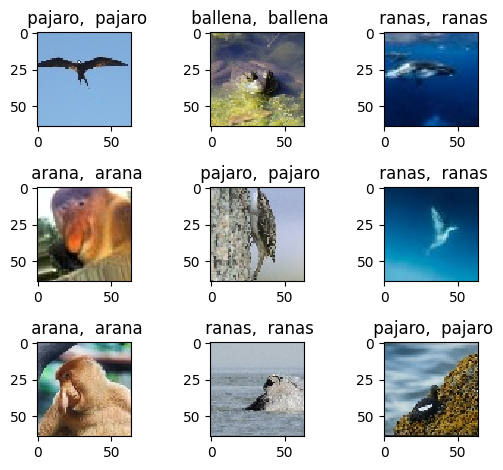

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if len(test_Y.shape) > 1:
    test_Y = np.argmax(test_Y, axis=1)

# 2. lista real de clases
animales = ['arana', 'ballena', 'mono', 'pajaro', 'ranas']

# 3. (Buscando los aciertos con '==')
correct = np.where(predicted_classes == test_Y)[0]
print("Found %d correct labels" % len(correct))

for i, c in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    
    # Renderizamos la foto sin el cmap='gray'
    plt.imshow(test_X[c].reshape(64,64,3), interpolation='none')
    
    # Ponemos el título jalando los nombres de tu lista 'animales'
    plt.title(" {},  {}".format(animales[predicted_classes[c]],
                                        animales[test_Y[c]]))
    plt.tight_layout()

plt.show()

Found 862 incorrect labels


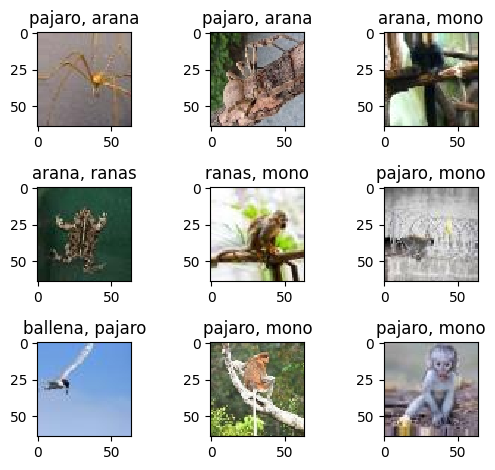

In [65]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(64,64,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                                                    deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [66]:
target_names = ["Class {}".format(i) for i in range(5)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.97      0.73      0.84      1305
     Class 1       0.88      0.89      0.88      1263
     Class 2       0.85      0.89      0.87      1264
     Class 3       0.75      0.88      0.81      1491
     Class 4       0.96      0.96      0.96      1252

    accuracy                           0.87      6575
   macro avg       0.88      0.87      0.87      6575
weighted avg       0.88      0.87      0.87      6575



In [67]:
print(nClasses)

5


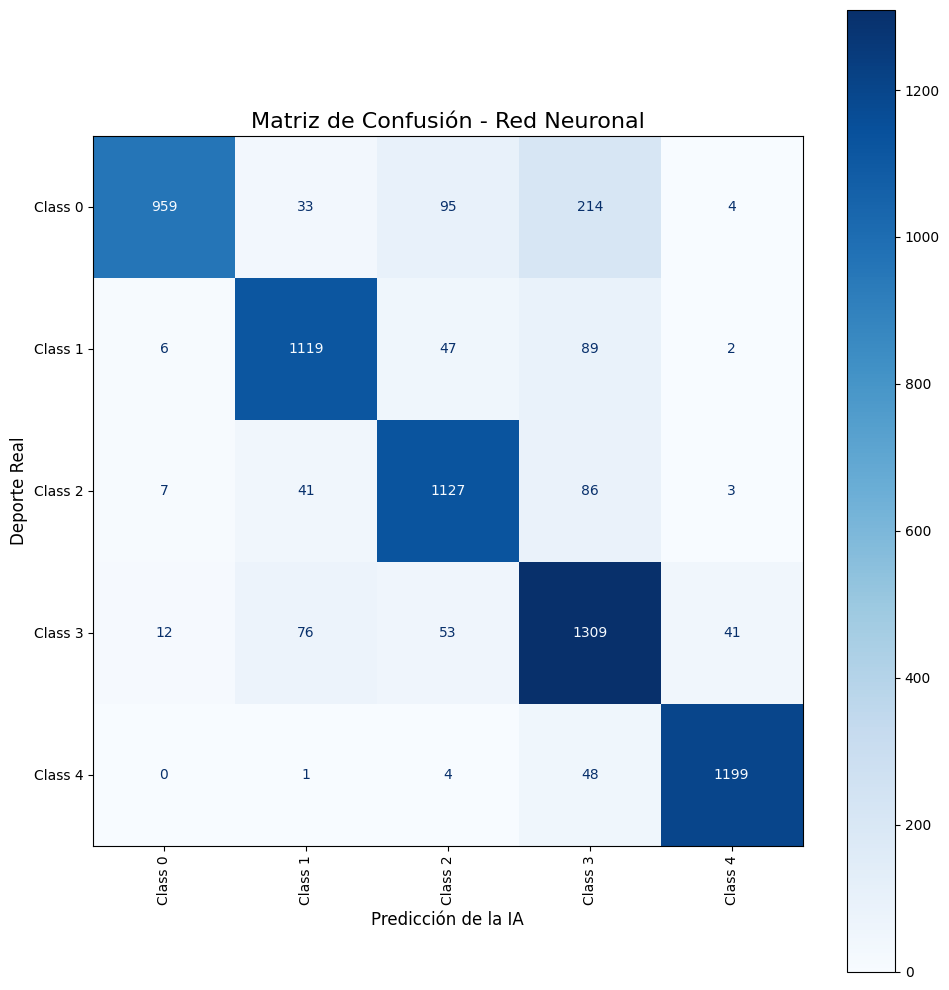

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de confusión matemáticamente
cm = confusion_matrix(test_Y, predicted_classes)

# 2. Le pasamos tu lista de 10 deportes para que ponga los nombres en los ejes
# (Asegúrate de que 'target_names' esté definido, si te marca error, 
#  cámbialo por la lista 'deportes' que usamos hace rato)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# 3. Configuramos el tamaño del lienzo para que no se amontonen las letras
fig, ax = plt.subplots(figsize=(10, 10))

# 4. Dibujamos la gráfica con un mapa de calor azul
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title("Matriz de Confusión - Red Neuronal", fontsize=16)
plt.xlabel("Predicción de la IA", fontsize=12)
plt.ylabel("Deporte Real", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model 

ruta_modelo = "/Users/dev/Desktop/IA/CNN/riesgo1.keras"  
if os.path.exists(ruta_modelo):
    mi_ia = load_model(ruta_modelo)
    print("¡Cerebro cargado con éxito!")
else:
    print("Error: No se encontró el archivo.")

ruta_foto = "/Users/dev/Desktop/IA/CNN/pajarotest7.png" 
image = cv2.imread(ruta_foto)
if image is not None:
    if image.shape[-1] == 4: 
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (64, 64)) 
    X_unica = np.array([image_resized], dtype='float32') / 255.0 
    prediccion = mi_ia.predict(X_unica, verbose=0)

    animales_5 = ['mono', 'ranas', 'arana', 'pajaro', 'ballena'] 
    
    # Muestra el porcentaje de confianza para cada clase, útil para detectar si el modelo está dudando
    print("\n📊 Probabilidades por clase:")
    for i, animal in enumerate(animales_5):
        print(f"  {animal}: {prediccion[0][i]*100:.2f}%")

    # Selecciona la clase con mayor probabilidad como predicción final
    indice_ganador = np.argmax(prediccion[0])
    porcentaje = np.max(prediccion[0]) * 100
    print("\n" + "="*40)
    print(f"PREDICCIÓN: ¡ES {animales_5[indice_ganador].upper()}!")
    print(f"Nivel de seguridad: {porcentaje:.2f}%")
    print("="*40)
else:
    print("Error: No encontré la foto de prueba.")

¡Cerebro cargado con éxito!

📊 Probabilidades por clase:
  mono: 0.00%
  ranas: 0.01%
  arana: 0.00%
  pajaro: 99.99%
  ballena: 0.00%

PREDICCIÓN: ¡ES PAJARO!
Nivel de seguridad: 99.99%


# VERIFICAR EL DATASET

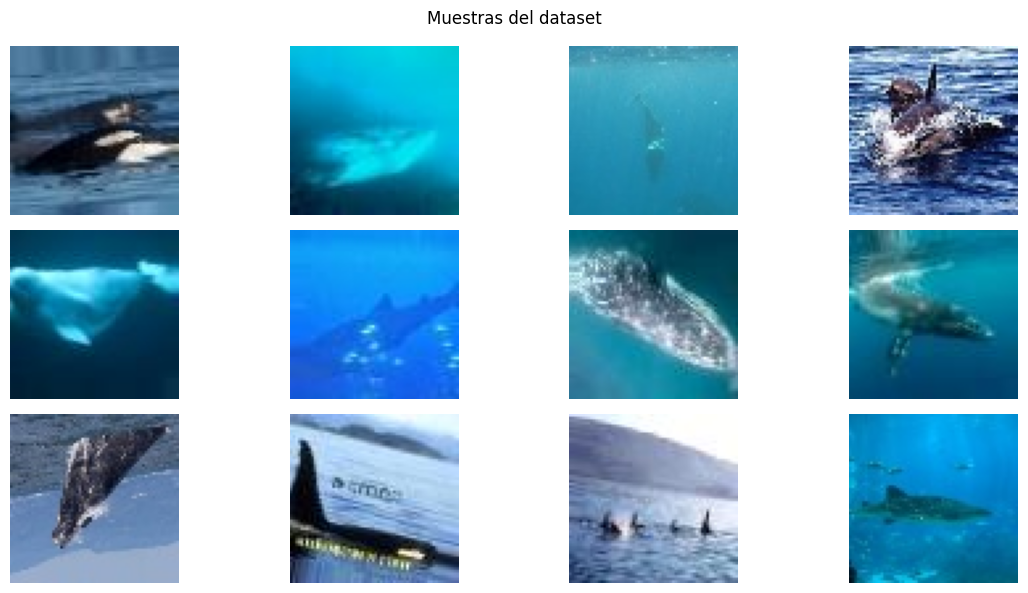

In [ ]:
#muestra de las imágenes que tiene el modelo
import matplotlib.pyplot as plt
import numpy as np

# Filtra solo las imágenes de la clase 
indices_mono = np.where(y == 4)[0]

plt.figure(figsize=(12, 6))
for i in range(min(12, len(indices_mono))):
    plt.subplot(3, 4, i+1)
    plt.imshow(X[indices_mono[i]])
    plt.axis('off')
plt.suptitle("Muestras del dataset")
plt.tight_layout()
plt.show()